In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
import os

In [2]:
# Data
data_path = os.path.join("..", "data", "IPL Auction (2013-2026).xlsx")
data = pd.read_excel(data_path)

data.head()

,Team,Player,Role,Value,Year
0,Chennai Super Kings,Christopher Morris,All-Rounder,625000,2013
1,Chennai Super Kings,Dirk Nannes,Bowler,600000,2013
2,Chennai Super Kings,Ben Laughlin,Bowler,20000,2013
3,Chennai Super Kings,Akila Dananjaya,All-Rounder,20000,2013
4,Chennai Super Kings,Jason Holder,Bowler,20000,2013


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Team    1381 non-null   str  
 1   Player  1381 non-null   str  
 2   Role    1122 non-null   str  
 3   Value   1381 non-null   int64
 4   Year    1381 non-null   int64
dtypes: int64(2), str(3)
memory usage: 54.1 KB


In [4]:
data["Value"] = data["Value"].apply(lambda x: float(re.sub(r"[?,/]", "", x)) if isinstance(x, str) else float(x))

In [5]:
df = data.copy()

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Team    1381 non-null   str    
 1   Player  1381 non-null   str    
 2   Role    1122 non-null   str    
 3   Value   1381 non-null   float64
 4   Year    1381 non-null   int64  
dtypes: float64(1), int64(1), str(3)
memory usage: 54.1 KB


In [7]:
years = sorted(df["Year"].unique())

for y in years:
    sub_df = df[df["Year"] == y].copy()

    # Min
    min_idx = sub_df["Value"].idxmin()
    min_auction = sub_df.loc[min_idx, "Value"]
    min_player = sub_df.loc[min_idx, "Player"]
    min_player_role = sub_df.loc[min_idx, "Role"]
    min_player_team = sub_df.loc[min_idx, "Team"]

    # Max
    max_idx = sub_df["Value"].idxmax()
    max_auction = sub_df.loc[max_idx, "Value"]
    max_player = sub_df.loc[max_idx, "Player"]
    max_player_role = sub_df.loc[max_idx, "Role"]
    max_player_team = sub_df.loc[max_idx, "Team"]

    # Median (pick closest value to median)
    median_auction = sub_df["Value"].median()
    median_idx = (sub_df["Value"] - median_auction).abs().idxmin()
    median_player = sub_df.loc[median_idx, "Player"]
    median_player_role = sub_df.loc[median_idx, "Role"]
    median_player_team = sub_df.loc[median_idx, "Team"]

    print(f"Year - {y}")
    print(f"Min. Auction    -> {min_player}, {min_player_role}, {min_player_team} -> INR {min_auction:.0f}")
    print(f"Max. Auction    -> {max_player}, {max_player_role}, {max_player_team} -> INR {max_auction:.0f}")
    print(f"Median (closest)-> {median_player}, {median_player_role}, {median_player_team} -> INR {median_auction:.0f}")
    print("--" * 10)

Year - 2013
Min. Auction    -> Ben Laughlin, Bowler, Chennai Super Kings -> INR 20000
Max. Auction    -> Glenn Maxwell, All-Rounder, Mumbai Indians -> INR 1000000
Median (closest)-> Luke Pomersbach, Batsman, Kings XI Punjab -> INR 300000
--------------------
Year - 2014
Min. Auction    -> Vijay Shankar, All-Rounder, Chennai Super Kings -> INR 1000000
Max. Auction    -> Yuvraj Singh, All-Rounder, Royal Challengers Bengaluru -> INR 140000000
Median (closest)-> Ben Hilfenhaus, Bowler, Chennai Super Kings -> INR 10000000
--------------------
Year - 2015
Min. Auction    -> Pratyush Singh, All-Rounder, Chennai Super Kings -> INR 1000000
Max. Auction    -> Yuvraj Singh, Batsman, Delhi Daredevils -> INR 160000000
Median (closest)-> Rahul Sharma, Bowler, Chennai Super Kings -> INR 3000000
--------------------
Year - 2016
Min. Auction    -> Chama Milind, Bowler, Delhi Daredevils -> INR 1000000
Max. Auction    -> Shane Watson, All-Rounder, Royal Challengers Bengaluru -> INR 95000000
Median (close

In [8]:
df["Value Cr"] = df["Value"] / 10000000
df["Value Lakh"] = df["Value"] / 100000

In [17]:
year_start = 2017

df2 = df[df["Year"]>=year_start]

In [18]:

df_group = df2.groupby(by=["Year"], as_index=False).agg(
    median_val = ("Value Lakh", "median"),
    mean_val = ("Value Lakh", "mean"),
    min_val = ("Value Lakh", "min"),
    max_val = ("Value Lakh", "max"),
    total_val = ("Value Lakh", "sum"),
    n_players = ("Value Lakh", "size")
)

df_group["per_player_val"] = df_group["total_val"]/df_group["n_players"]

df_group

,Year,median_val,mean_val,min_val,max_val,total_val,n_players,per_player_val
0,2017,40.0,138.106061,10.0,1450.0,9115.0,66,138.106061
1,2018,170.0,255.443787,20.0,1250.0,43170.0,169,255.443787
2,2019,75.0,178.000000,20.0,840.0,10680.0,60,178.000000
3,2020,90.0,226.290323,20.0,1550.0,14030.0,62,226.290323
4,2021,50.0,254.912281,20.0,1625.0,14530.0,57,254.912281
5,2022,105.0,270.441176,20.0,1525.0,55170.0,204,270.441176
6,2023,50.0,208.750000,20.0,1850.0,16700.0,80,208.750000
7,2024,125.0,320.069444,20.0,2475.0,23045.0,72,320.069444
8,2025,150.0,351.181319,30.0,2700.0,63915.0,182,351.181319
9,2026,100.0,279.805195,30.0,2520.0,21545.0,77,279.805195


In [19]:
df_group["length"] = df_group["n_players"]//10

In [20]:

df2.head()

,Team,Player,Role,Value,Year,Value Cr,Value Lakh
352,Delhi Daredevils,Kagiso Rabada,Bowler,50000000.0,2017,5.0,500.0
353,Delhi Daredevils,Patrick Cummins,Bowler,45000000.0,2017,4.5,450.0
354,Delhi Daredevils,Angelo Mathews,All-Rounder,20000000.0,2017,2.0,200.0
355,Delhi Daredevils,Corey Anderson,All-Rounder,10000000.0,2017,1.0,100.0
356,Delhi Daredevils,M. Ashwin,Bowler,10000000.0,2017,1.0,100.0


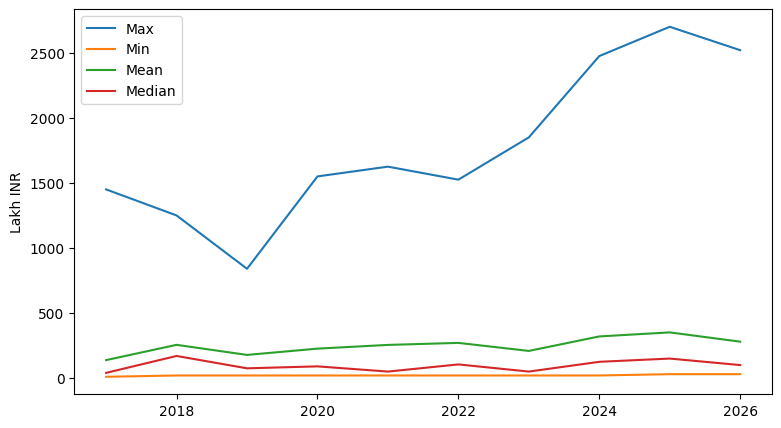

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(df_group["Year"], df_group["max_val"], label="Max")
ax.plot(df_group["Year"], df_group["min_val"], label="Min")
ax.plot(df_group["Year"], df_group["mean_val"], label="Mean")
ax.plot(df_group["Year"], df_group["median_val"], label="Median")

ax.legend()

ax.set_ylabel("Lakh INR")

plt.show()

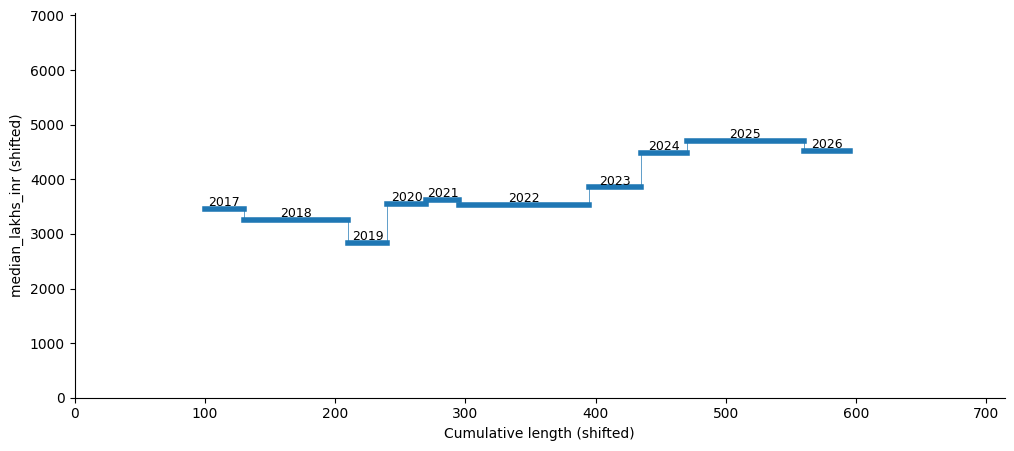

In [37]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# tweak knobs
line_thickness = 4
y_offset = 2000      # shifts everything UP/DOWN (add to every y)
x_offset = 100      # shifts everything RIGHT/LEFT (add to every x)
length_mag = 5

fig, ax = plt.subplots(figsize=(12, 5))

x_cursor = 0
prev_end_x = None
prev_y = None

for _, r in df_group.sort_values("Year").iterrows():
    year = r["Year"]

    # apply y shift
    y = r["max_val"] + y_offset

    seg_len = r["length"]*length_mag

    # base segment positions
    x_start_base = x_cursor
    x_end_base = x_cursor + seg_len

    # apply x shift (same offset added to both ends)
    x_start = x_start_base + x_offset
    x_end = x_end_base + x_offset

    # thick horizontal line for the year
    ax.add_line(Line2D(
        [x_start, x_end],
        [y, y],
        linewidth=line_thickness
    ))

    # optional: thin vertical connector between years
    if prev_end_x is not None:
        ax.add_line(Line2D(
            [x_start, x_start],
            [prev_y, y],
            linewidth=0.5
        ))

    # optional: year label
    ax.text((x_start + x_end) / 2, y, str(int(year)), ha="center", va="bottom", fontsize=9)

    # update "previous" using the shifted coordinates (so connectors align perfectly)
    prev_end_x = x_end
    prev_y = y

    # advance cursor in base space (so segment lengths remain unchanged)
    x_cursor = x_end_base

# axis limits must account for offsets
ax.set_xlim(0, (x_offset + x_cursor)*1.2)
ax.set_ylim(0, (df_group["max_val"].max() + y_offset) * 1.5)

ax.set_xlabel("Cumulative length (shifted)")
ax.set_ylabel("median_lakhs_inr (shifted)")
ax.spines[["top", "right"]].set_visible(False)

plt.show()

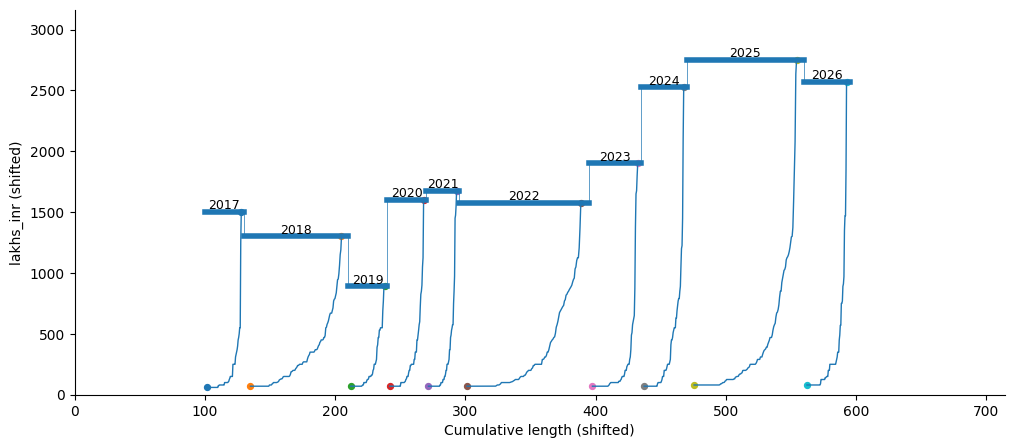

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def even_slot_midpoints(x_start: float, x_end: float, n_points: int, pad_frac: float = 0.06) -> np.ndarray:
    """Evenly place n_points inside [x_start, x_end] using slot midpoints, with padding."""
    if n_points <= 0:
        return np.array([])

    seg_len = x_end - x_start
    pad = seg_len * pad_frac
    x_left = x_start + pad
    x_right = x_end - pad

    if x_right <= x_left:  # segment too small
        return np.full(n_points, (x_start + x_end) / 2)

    slot_edges = np.linspace(x_left, x_right, n_points + 1)
    return (slot_edges[:-1] + slot_edges[1:]) / 2

# ---------------------------
# tweak knobs
line_thickness = 4
y_offset = 50      # shifts everything UP/DOWN
x_offset = 100     # shifts everything RIGHT/LEFT
length_mag = 5

dist_line_width = 1.0
end_dot_size = 18
pad_frac = 0.06

# if a year has too many players, compress to representative quantiles (keeps curve shape)
max_points_per_year = 140  # set None to plot all (may get heavy)

fig, ax = plt.subplots(figsize=(12, 5))

x_cursor = 0
prev_end_x = None
prev_y = None

for _, r in df_group.sort_values("Year").iterrows():
    year = int(r["Year"])
    y_base = r["max_val"] + y_offset

    seg_len = r["length"] * length_mag

    x_start_base = x_cursor
    x_end_base = x_cursor + seg_len

    x_start = x_start_base + x_offset
    x_end = x_end_base + x_offset

    # thick baseline (median)
    ax.add_line(Line2D([x_start, x_end], [y_base, y_base], linewidth=line_thickness))

    # connector
    if prev_end_x is not None:
        ax.add_line(Line2D([x_start, x_start], [prev_y, y_base], linewidth=0.5))

    # year label
    ax.text((x_start + x_end) / 2, y_base, str(year), ha="center", va="bottom", fontsize=9)

    # ---------------------------
    # distribution curve line (values sorted)
    year_vals = df2.loc[df2["Year"] == year, "Value Lakh"].to_numpy(dtype=float)
    if year_vals.size > 0:
        if max_points_per_year is not None and year_vals.size > max_points_per_year:
            q = np.linspace(0, 1, max_points_per_year)
            year_vals = np.quantile(year_vals, q)

        year_vals_sorted = np.sort(year_vals)

        n_pts = year_vals_sorted.size
        x_pts = even_slot_midpoints(x_start, x_end, n_pts, pad_frac=pad_frac)
        y_pts = year_vals_sorted + y_offset

        # thin line connecting distribution
        ax.add_line(Line2D(x_pts, y_pts, linewidth=dist_line_width))

        # optional: endpoints only (very low clutter)
        ax.scatter([x_pts[0], x_pts[-1]], [y_pts[0], y_pts[-1]], s=end_dot_size)

    # update previous + cursor
    prev_end_x = x_end
    prev_y = y_base
    x_cursor = x_end_base

# axis limits
y_max = max(df_group["max_val"].max(), df2["Value Lakh"].max()) + y_offset
ax.set_xlim(0, (x_offset + x_cursor) * 1.2)
ax.set_ylim(0, y_max * 1.15)

ax.set_xlabel("Cumulative length (shifted)")
ax.set_ylabel("lakhs_inr (shifted)")
ax.spines[["top", "right"]].set_visible(False)

plt.show()

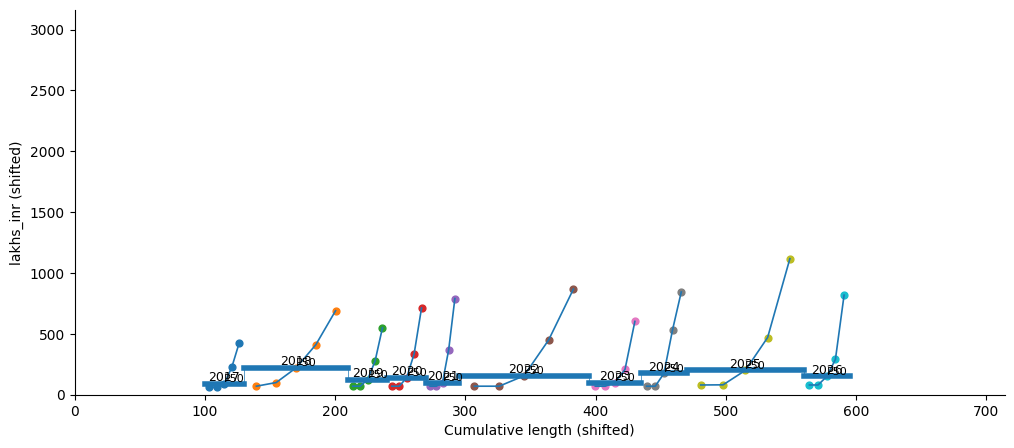

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------
# tweak knobs
line_thickness = 4
y_offset = 50
x_offset = 100
length_mag = 5

pct_line_width = 1.2
pct_dot_size = 24

# choose your summary points (edit freely)
percentiles = np.array([10, 25, 50, 75, 90], dtype=float)

# where inside the segment to draw this percentile line (keeps it visually centered)
left_frac = 0.12
right_frac = 0.12

fig, ax = plt.subplots(figsize=(12, 5))

x_cursor = 0
prev_end_x = None
prev_y = None

for _, r in df_group.sort_values("Year").iterrows():
    year = int(r["Year"])
    y_base = r["median_val"] + y_offset

    seg_len = r["length"] * length_mag

    x_start_base = x_cursor
    x_end_base = x_cursor + seg_len

    x_start = x_start_base + x_offset
    x_end = x_end_base + x_offset

    # thick baseline (median)
    ax.add_line(Line2D([x_start, x_end], [y_base, y_base], linewidth=line_thickness))

    # connector
    if prev_end_x is not None:
        ax.add_line(Line2D([x_start, x_start], [prev_y, y_base], linewidth=0.5))

    # year label
    ax.text((x_start + x_end) / 2, y_base, str(year), ha="center", va="bottom", fontsize=9)

    # ---------------------------
    # percentile line
    year_vals = df2.loc[df2["Year"] == year, "Value Lakh"].to_numpy(dtype=float)
    if year_vals.size > 0:
        y_pts = np.percentile(year_vals, percentiles) + y_offset

        seg_span = x_end - x_start
        x_left = x_start + seg_span * left_frac
        x_right = x_end - seg_span * right_frac
        x_pts = np.linspace(x_left, x_right, len(percentiles))

        ax.add_line(Line2D(x_pts, y_pts, linewidth=pct_line_width))
        ax.scatter(x_pts, y_pts, s=pct_dot_size)

        # optional: label the median percentile point (P50)
        # Find index of 50 in percentiles (if present)
        if np.any(percentiles == 50):
            idx_50 = int(np.where(percentiles == 50)[0][0])
            ax.text(x_pts[idx_50], y_pts[idx_50], "P50", ha="left", va="bottom", fontsize=8)

    # update previous + cursor
    prev_end_x = x_end
    prev_y = y_base
    x_cursor = x_end_base

# axis limits
y_max = max(df_group["median_val"].max(), df2["Value Lakh"].max()) + y_offset
ax.set_xlim(0, (x_offset + x_cursor) * 1.2)
ax.set_ylim(0, y_max * 1.15)

ax.set_xlabel("Cumulative length (shifted)")
ax.set_ylabel("lakhs_inr (shifted)")
ax.spines[["top", "right"]].set_visible(False)

plt.show()

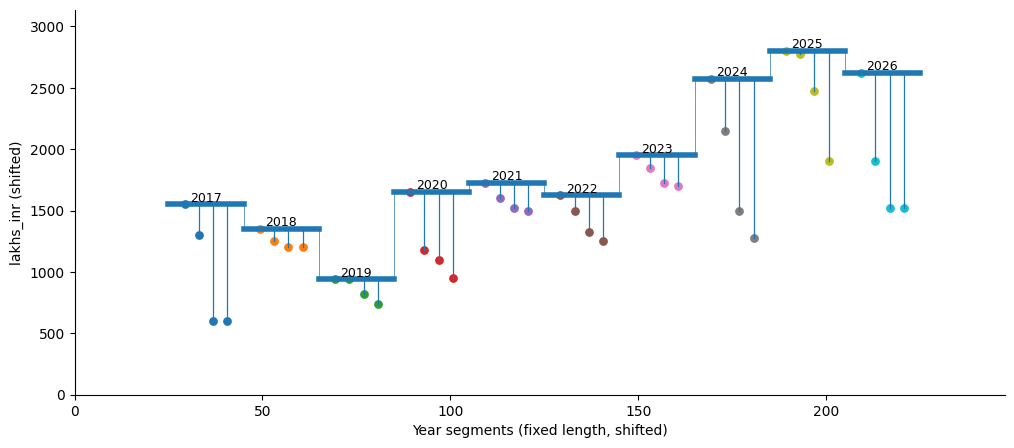

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------
# tweak knobs
line_thickness = 4
y_offset = 100       # shifts everything UP/DOWN (add to every y)
x_offset = 25      # shifts everything RIGHT/LEFT (add to every x)

line_length = 20    # SAME length for every median segment (in x-units)
n_top = 4           # top N deals (lollipops) per year

stem_thickness = 0.9
dot_size = 28
pad_frac = 0.12     # padding inside segment for lollipop x positions

# spacing between year segments (since all same length)
gap = 0

# ---------------------------
def even_slot_midpoints(x_start: float, x_end: float, n_points: int, pad_frac: float = 0.12) -> np.ndarray:
    """Evenly place n_points inside [x_start, x_end] using slot midpoints, with padding."""
    if n_points <= 0:
        return np.array([])

    seg_len = x_end - x_start
    pad = seg_len * pad_frac
    x_left = x_start + pad
    x_right = x_end - pad

    if x_right <= x_left:
        return np.full(n_points, (x_start + x_end) / 2)

    slot_edges = np.linspace(x_left, x_right, n_points + 1)
    return (slot_edges[:-1] + slot_edges[1:]) / 2

# ---------------------------
fig, ax = plt.subplots(figsize=(12, 5))

x_cursor = 0
prev_start_x = None
prev_y = None

for _, r in df_group.sort_values("Year").iterrows():
    year = int(r["Year"])
    y_base = r["max_val"] + y_offset

    # SAME segment length for each year
    x_start_base = x_cursor
    x_end_base = x_cursor + line_length

    # apply x shift
    x_start = x_start_base + x_offset
    x_end = x_end_base + x_offset

    # thick horizontal median line
    ax.add_line(Line2D([x_start, x_end], [y_base, y_base], linewidth=line_thickness))

    # thin connector (start-to-start, so it looks like a "timeline spine")
    if prev_start_x is not None:
        ax.add_line(Line2D([x_start, x_start], [prev_y, y_base], linewidth=0.5))

    # year label
    ax.text((x_start + x_end) / 2, y_base, str(year), ha="center", va="bottom", fontsize=9)

    # ---------------------------
    # TOP-N lollipops for that year
    year_vals = df2.loc[df2["Year"] == year, "Value Lakh"].to_numpy(dtype=float)

    if year_vals.size > 0:
        # pick top N (descending)
        top_vals = np.sort(year_vals)[::-1][:n_top]

        # evenly spread across this fixed segment
        x_pts = even_slot_midpoints(x_start, x_end, top_vals.size, pad_frac=pad_frac)
        y_tips = top_vals + y_offset  # same y shift as everything

        # stems + heads
        for xi, yi in zip(x_pts, y_tips):
            ax.add_line(Line2D([xi, xi], [y_base, yi], linewidth=stem_thickness))
        ax.scatter(x_pts, y_tips, s=dot_size)

    # ---------------------------
    prev_start_x = x_start
    prev_y = y_base

    # advance cursor in base space (fixed length + gap)
    x_cursor = x_end_base + gap

# axis limits
y_max = max(df_group["max_val"].max(), df2["Value Lakh"].max()) + y_offset
ax.set_xlim(0, (x_offset + x_cursor) * 1.1)
ax.set_ylim(0, y_max * 1.12)

ax.set_xlabel("Year segments (fixed length, shifted)")
ax.set_ylabel("lakhs_inr (shifted)")
ax.spines[["top", "right"]].set_visible(False)

plt.show()

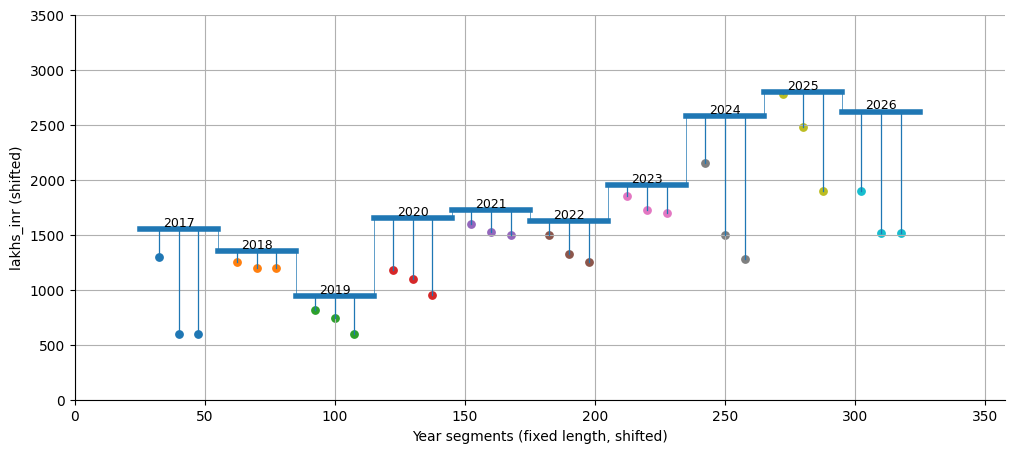

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------
# tweak knobs
line_thickness = 4
y_offset = 100       # shifts everything UP/DOWN (add to every y)
x_offset = 25        # shifts everything RIGHT/LEFT (add to every x)

line_length = 30     # SAME length for every thick segment (in x-units)
n_top = 3            # plot top N values AFTER the max (i.e., 2nd..(N+1)th)

stem_thickness = 0.9
dot_size = 28
pad_frac = 0.12      # padding inside segment for lollipop x positions

# spacing between year segments (since all same length)
gap = 0

# ---------------------------
def even_slot_midpoints(x_start: float, x_end: float, n_points: int, pad_frac: float = 0.12) -> np.ndarray:
    """Evenly place n_points inside [x_start, x_end] using slot midpoints, with padding."""
    if n_points <= 0:
        return np.array([])

    seg_len = x_end - x_start
    pad = seg_len * pad_frac
    x_left = x_start + pad
    x_right = x_end - pad

    if x_right <= x_left:
        return np.full(n_points, (x_start + x_end) / 2)

    slot_edges = np.linspace(x_left, x_right, n_points + 1)
    return (slot_edges[:-1] + slot_edges[1:]) / 2

# ---------------------------
fig, ax = plt.subplots(figsize=(12, 5))

x_cursor = 0
prev_start_x = None
prev_y = None

for _, r in df_group.sort_values("Year").iterrows():
    year = int(r["Year"])

    # thick line is at MAX value for that year (shifted)
    y_base = float(r["max_val"]) + y_offset

    # SAME segment length for each year
    x_start_base = x_cursor
    x_end_base = x_cursor + line_length

    # apply x shift
    x_start = x_start_base + x_offset
    x_end = x_end_base + x_offset

    # thick horizontal max line
    ax.add_line(Line2D([x_start, x_end], [y_base, y_base], linewidth=line_thickness))

    # thin connector (start-to-start)
    if prev_start_x is not None:
        ax.add_line(Line2D([x_start, x_start], [prev_y, y_base], linewidth=0.5))

    # year label
    ax.text((x_start + x_end) / 2, y_base, str(year), ha="center", va="bottom", fontsize=9)

    # ---------------------------
    # LOLLIPOPS: top N values AFTER the max (i.e., exclude the maximum itself)
    year_vals = df2.loc[df2["Year"] == year, "Value Lakh"].to_numpy(dtype=float)

    if year_vals.size > 0:
        # sort descending
        sorted_desc = np.sort(year_vals)[::-1]

        # drop ALL occurrences of the max value (so if max repeats, none of them become lollipops)
        max_val = sorted_desc[0]
        after_max = sorted_desc[sorted_desc < max_val]

        # take next top N
        top_vals = after_max[:n_top]

        # equispaced positions across this thick line
        x_pts = even_slot_midpoints(x_start, x_end, top_vals.size, pad_frac=pad_frac)
        y_tips = top_vals + y_offset

        # stems + heads
        for xi, yi in zip(x_pts, y_tips):
            ax.add_line(Line2D([xi, xi], [y_base, yi], linewidth=stem_thickness))
        ax.scatter(x_pts, y_tips, s=dot_size)

    # ---------------------------
    prev_start_x = x_start
    prev_y = y_base

    # advance cursor in base space (fixed length + gap)
    x_cursor = x_end_base + gap

# axis limits
y_max = max(df_group["max_val"].max(), df2["Value Lakh"].max()) + y_offset
ax.set_xlim(0, (x_offset + x_cursor) * 1.1)
ax.set_ylim(0, y_max * 1.25)

ax.set_xlabel("Year segments (fixed length, shifted)")
ax.set_ylabel("lakhs_inr (shifted)")
ax.spines[["top", "right"]].set_visible(False)

ax.grid()

plt.show()